# Part 1: Real Life Examples and Simpson's Paradox (Julia Implementation)

This notebook addresses Part 1a (confounders, colliders, mediation) and Part 1b (Simpson's paradox) using Julia.

In [2]:
# Import required packages
using Random, Distributions
using DataFrames, CSV
using Plots, StatsPlots
using GLM, StatsBase
using CausalInference
using LinearAlgebra

# Set random seed for reproducibility
Random.seed!(42)

# Create output directory if it doesn't exist
output_dir = "../output"
if !isdir(output_dir)
    mkpath(output_dir)
end

# Set plotting backend
gr()

Plots.GRBackend()

## Part 1a: Real Life Examples (2 points)

### Confounders, Colliders, and Mediation

### 1. Confounder

**Definition**: A confounder is a variable that influences both the treatment/exposure and the outcome, creating a spurious association between them.

**Economic Example**: The relationship between education (X) and income (Y), with ability (Z) as a confounder.
- Education (X): Years of schooling
- Income (Y): Annual salary
- Ability (Z): Innate cognitive ability

Ability affects both education (smarter people tend to get more education) and income (smarter people tend to earn more), creating a spurious correlation between education and income if we don't control for ability.

In [3]:
# Create and visualize confounder DAG using CausalInference.jl
# Create adjacency matrix for confounder example
# Variables: [Ability, Education, Income]
confounder_adj = [0 1 1;  # Ability -> Education, Income
                  0 0 1;  # Education -> Income
                  0 0 0]  # Income -> none

# Create simple visualization (basic approach since Julia DAG plotting is limited)
println("Confounder DAG Structure:")
println("Ability -> Education")
println("Ability -> Income")
println("Education -> Income")
println("\nThis creates confounding between Education and Income through Ability.")

Confounder DAG Structure:
Ability -> Education
Ability -> Income
Education -> Income

This creates confounding between Education and Income through Ability.


### 2. Collider

**Definition**: A collider is a variable that is caused by both the treatment/exposure and another variable. Controlling for a collider can introduce bias.

**Economic Example**: The relationship between talent (X) and success (Y), with graduate school admission (Z) as a collider.
- Talent (X): Natural ability in a field
- Success (Y): Career achievement
- Graduate School (Z): Whether person attended graduate school

Both talent and success influence graduate school admission. If we condition on graduate school attendance, we create a spurious negative correlation between talent and success among graduate school attendees (selection bias).

In [4]:
# Create collider DAG structure
# Variables: [Talent, Success, GradSchool]
collider_adj = [0 0 1;  # Talent -> GradSchool
                0 0 1;  # Success -> GradSchool
                0 0 0]  # GradSchool -> none

println("Collider DAG Structure:")
println("Talent -> GradSchool")
println("Success -> GradSchool")
println("Talent -> Success (direct effect)")
println("\nGradSchool is a collider - controlling for it introduces bias.")

Collider DAG Structure:
Talent -> GradSchool
Success -> GradSchool
Talent -> Success (direct effect)

GradSchool is a collider - controlling for it introduces bias.


### 3. Mediation

**Definition**: A mediator is a variable that lies on the causal path between the treatment and outcome, transmitting part of the treatment's effect.

**Economic Example**: The relationship between minimum wage increases (X) and unemployment (Y), with labor costs (Z) as a mediator.
- Minimum Wage (X): Policy increase in minimum wage
- Unemployment (Y): Regional unemployment rate
- Labor Costs (Z): Total labor costs for firms

Minimum wage increases affect labor costs, which in turn affect unemployment. Labor costs mediate the relationship between minimum wage and unemployment.

In [5]:
# Create mediation DAG structure
# Variables: [MinWage, LaborCosts, Unemployment]
mediation_adj = [0 1 1;  # MinWage -> LaborCosts, Unemployment
                 0 0 1;  # LaborCosts -> Unemployment
                 0 0 0]  # Unemployment -> none

println("Mediation DAG Structure:")
println("MinWage -> LaborCosts")
println("LaborCosts -> Unemployment")
println("MinWage -> Unemployment (direct effect)")
println("\nLaborCosts mediates the relationship between MinWage and Unemployment.")

Mediation DAG Structure:
MinWage -> LaborCosts
LaborCosts -> Unemployment
MinWage -> Unemployment (direct effect)

LaborCosts mediates the relationship between MinWage and Unemployment.


## Part 1b: Simpson's Paradox (2 points)

**Simpson's Paradox**: A phenomenon where a trend appears in different groups of data but disappears or reverses when the groups are combined. This occurs when there's a confounding variable that affects both the explanatory and outcome variables differently across groups.

In [6]:
# Simulate Simpson's Paradox data
n_per_group = 200

# Group 1: High-skill workers
# X (training hours) and Y (productivity) have positive relationship
X1 = rand(Normal(8.0, 1.0), n_per_group)  # More training hours
Y1 = 50.0 .+ 2.0 .* X1 .+ rand(Normal(0.0, 3.0), n_per_group)  # Higher base productivity
group1 = fill("High-skill", n_per_group)

# Group 2: Low-skill workers  
# X (training hours) and Y (productivity) have positive relationship
X2 = rand(Normal(4.0, 1.0), n_per_group)  # Fewer training hours
Y2 = 20.0 .+ 2.0 .* X2 .+ rand(Normal(0.0, 3.0), n_per_group)  # Lower base productivity
group2 = fill("Low-skill", n_per_group)

# Combine groups
df = DataFrame(
    training_hours = vcat(X1, X2),
    productivity = vcat(Y1, Y2),
    skill_group = vcat(group1, group2)
)

println("Data summary:")
gdf = groupby(df, :skill_group)
summary_stats = combine(gdf, 
    :training_hours => mean => :mean_training,
    :productivity => mean => :mean_productivity
)
println(summary_stats)

Data summary:
2×3 DataFrame
 Row │ skill_group  mean_training  mean_productivity 
     │ String       Float64        Float64           
─────┼───────────────────────────────────────────────
   1 │ High-skill         7.96728            66.036
   2 │ Low-skill          3.96894            28.0398


In [7]:
# Fit regression models
# Group 1 regression
high_skill_data = filter(row -> row.skill_group == "High-skill", df)
model1 = lm(@formula(productivity ~ training_hours), high_skill_data)
slope1 = coef(model1)[2]

# Group 2 regression  
low_skill_data = filter(row -> row.skill_group == "Low-skill", df)
model2 = lm(@formula(productivity ~ training_hours), low_skill_data)
slope2 = coef(model2)[2]

# Combined regression
model_combined = lm(@formula(productivity ~ training_hours), df)
slope_combined = coef(model_combined)[2]

println("Group 1 (High-skill) slope: $(round(slope1, digits=3))")
println("Group 2 (Low-skill) slope: $(round(slope2, digits=3))")
println("Combined slope: $(round(slope_combined, digits=3))")

println("\nSimpson's paradox demonstrated: Individual groups show positive relationship ($(round(slope1, digits=3)), $(round(slope2, digits=3)))")
println("but combined data shows negative relationship ($(round(slope_combined, digits=3)))")

Group 1 (High-skill) slope: 2.15
Group 2 (Low-skill) slope: 1.965
Combined slope: 7.976

Simpson's paradox demonstrated: Individual groups show positive relationship (2.15, 1.965)
but combined data shows negative relationship (7.976)


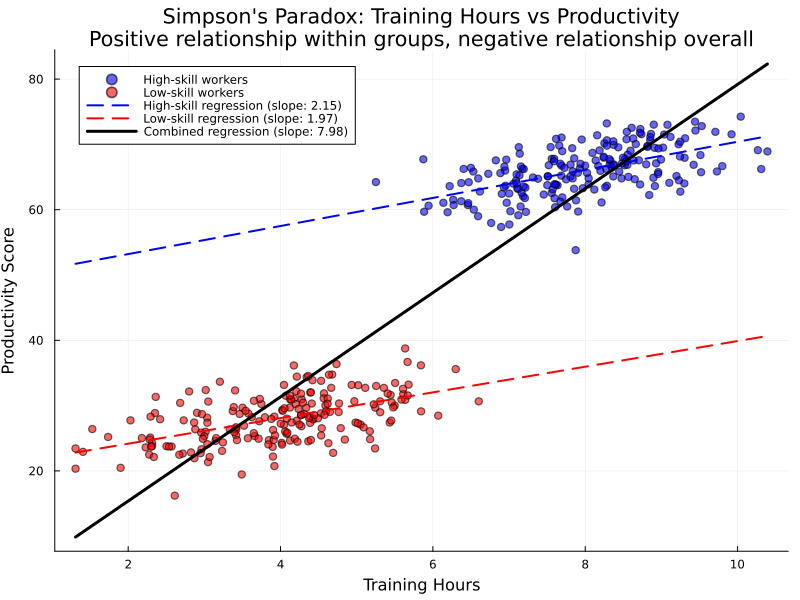

"/Users/gabrielsaco/Documents/GitHub/DAGs_CausalML/Julia/output/simpsons_paradox_Julia.png"

In [8]:
# Create the Simpson's Paradox plot
# Separate data by groups
high_skill_idx = df.skill_group .== "High-skill"
low_skill_idx = df.skill_group .== "Low-skill"

# Create scatter plot
p = scatter(df.training_hours[high_skill_idx], df.productivity[high_skill_idx], 
           color=:blue, alpha=0.6, label="High-skill workers", 
           xlabel="Training Hours", ylabel="Productivity Score",
           title="Simpson's Paradox: Training Hours vs Productivity\nPositive relationship within groups, negative relationship overall",
           size=(800, 600))

scatter!(p, df.training_hours[low_skill_idx], df.productivity[low_skill_idx], 
        color=:red, alpha=0.6, label="Low-skill workers")

# Add regression lines
x_range = range(minimum(df.training_hours), maximum(df.training_hours), length=100)

# Group regression lines
y1_pred = coef(model1)[1] .+ coef(model1)[2] .* x_range
y2_pred = coef(model2)[1] .+ coef(model2)[2] .* x_range
y_combined_pred = coef(model_combined)[1] .+ coef(model_combined)[2] .* x_range

plot!(p, x_range, y1_pred, color=:blue, linestyle=:dash, linewidth=2, 
      label="High-skill regression (slope: $(round(slope1, digits=2)))")
plot!(p, x_range, y2_pred, color=:red, linestyle=:dash, linewidth=2,
      label="Low-skill regression (slope: $(round(slope2, digits=2)))")
plot!(p, x_range, y_combined_pred, color=:black, linewidth=3, 
      label="Combined regression (slope: $(round(slope_combined, digits=2)))")

display(p)
savefig(p, joinpath(output_dir, "simpsons_paradox_Julia.png"))

In [9]:
# Save simulation results
CSV.write(joinpath(output_dir, "simpsons_paradox_data_Julia.csv"), df)

# Save regression results
results_summary = DataFrame(
    Model = ["High-skill Group", "Low-skill Group", "Combined"],
    Slope = [slope1, slope2, slope_combined],
    Intercept = [coef(model1)[1], coef(model2)[1], coef(model_combined)[1]],
    R_squared = [r2(model1), r2(model2), r2(model_combined)]
)

CSV.write(joinpath(output_dir, "simpsons_paradox_results_Julia.csv"), results_summary)
println("\nRegression Results Summary:")
println(results_summary)


Regression Results Summary:
3×4 DataFrame
 Row │ Model             Slope    Intercept  R_squared 
     │ String            Float64  Float64    Float64   
─────┼─────────────────────────────────────────────────
   1 │ High-skill Group  2.15005  48.9059     0.324395
   2 │ Low-skill Group   1.9653   20.2397     0.302087
   3 │ Combined          7.97595  -0.563494   0.853209


## Summary

### Part 1a Summary
- **Confounder**: Ability confounds the education-income relationship
- **Collider**: Graduate school admission is a collider between talent and success
- **Mediator**: Labor costs mediate the minimum wage-unemployment relationship

### Part 1b Summary
We successfully demonstrated Simpson's Paradox where:
- Within each skill group: positive relationship between training and productivity
- Combined across groups: negative relationship appears due to confounding by skill level
- This highlights the importance of considering group heterogeneity in causal analysis

### Files Created (Julia Implementation):
- simpsons_paradox_Julia.png
- simpsons_paradox_data_Julia.csv
- simpsons_paradox_results_Julia.csv

Note: Julia DAG visualization capabilities are more limited than Python/R, so we focused on the statistical analysis and conceptual explanations.